[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/heitorramos/icd/blob/main/exemplos/12-bootstrap/notebook-colab.ipynb)


In [ ]:
# Preparação automática para execução no Google Colab.
# Fora do Colab, esta célula não altera o diretório de trabalho.
try:
    import google.colab  # type: ignore
except ImportError:
    pass
else:
    import os
    import subprocess
    from pathlib import Path

    repository = Path("/content/icd")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/heitorramos/icd.git", str(repository)
        ], check=True)
    os.chdir(repository / "exemplos/12-bootstrap")
    print("Material preparado em:", Path.cwd())


# Airbnb NYC 2019: uma introdução ao bootstrap

## Objetivos e roteiro de estudo

O bootstrap aproxima a distribuição amostral usando a própria amostra
como uma população empírica. Este capítulo explica por que reamostramos
**com reposição**, como cada réplica é construída, o que a distribuição
das réplicas representa e como ela pode ser usada para estimar erro
padrão, viés e intervalos de confiança.

O raciocínio deve ser acompanhado em três níveis. A amostra original
produz a estimativa observada. Cada reamostra produz uma réplica
bootstrap. O conjunto de muitas réplicas aproxima a variabilidade que
teríamos ao repetir a coleta sob condições semelhantes. Não confunda a
quantidade de réplicas com o tamanho da amostra: aumentar $R$ reduz o
ruído da simulação, mas não cria novas observações independentes.

Nesta aula, $R$ denota o número total de réplicas e $b$ indexa uma
réplica particular. Essa escolha preserva $B(\widehat\theta)$ para o
viés do estimador, seguindo a notação adotada nas aulas anteriores.

Começaremos com o intervalo percentil e depois compararemos outros
métodos. As fórmulas são acompanhadas de interpretação, vantagens e
limitações. Antes de escolher um intervalo, verifique se as observações
são representativas, se a unidade de reamostragem respeita a dependência
dos dados e se a estatística não está em uma situação muito irregular.

## A base

A base Airbnb NYC 2019 descreve anúncios disponíveis na cidade de Nova
York. A unidade de observação é um anúncio. Usaremos distrito, tipo de
acomodação, preço por noite e identificador do anfitrião.

In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = kagglehub.dataset_download(
    "dgomonov/new-york-city-airbnb-open-data"
)
airbnb = pd.read_csv(f"{path}/AB_NYC_2019.csv")
airbnb.shape

> **Interpretação**
>
> Antes de interpretar resultados, confirme o que cada linha representa,
> o período coberto e as colunas realmente disponíveis. Essa definição
> determina quais agregações e comparações são válidas.

## Panorama descritivo

In [ ]:
airbnb[["price", "minimum_nights", "availability_365"]].describe()

In [ ]:
airbnb["neighbourhood_group"].value_counts()

In [ ]:
airbnb[["price", "neighbourhood_group", "room_type", "host_id"]].isna().sum()

> **Interpretação**
>
> Os resumos devem ser lidos em conjunto: preço e noites mínimas são
> assimétricos, os bairros têm tamanhos diferentes e valores ausentes
> podem alterar a população efetivamente analisada. Esses fatos orientam
> o filtro, a escolha da mediana e a forma de reamostrar.

## Limpeza e população-alvo

Removemos preços zero e o 1% superior. A análise compara acomodações
inteiras em Manhattan e Brooklyn. Os filtros fazem parte da definição da
população-alvo.

In [ ]:
limite = airbnb["price"].quantile(.99)

focus = airbnb[
    airbnb["price"].between(1, limite)
    & airbnb["room_type"].eq("Entire home/apt")
    & airbnb["neighbourhood_group"].isin(["Manhattan", "Brooklyn"])
].copy()

sample = focus.groupby("neighbourhood_group", group_keys=False).sample(
    n=600, random_state=1105
)

> **Interpretação**
>
> O bootstrap descreve incerteza condicionada à amostra observada. Sua
> validade depende de representatividade, independência adequada e
> escolha correta da unidade de reamostragem.

## Estimativa observada

In [ ]:
prices = {
    borough: group["price"].to_numpy()
    for borough, group in sample.groupby("neighbourhood_group")
}

theta_hat = (
    np.median(prices["Manhattan"])
    - np.median(prices["Brooklyn"])
)
theta_hat

> **Interpretação**
>
> A diferença observada é o centro da análise, mas não informa sozinha
> sua precisão. O bootstrap aproxima essa incerteza reamostrando
> unidades comparáveis da amostra.

## Por que o intervalo analítico para medianas é mais difícil?

Para uma média, o TCL fornece uma aproximação Normal e o erro padrão
pode ser estimado diretamente pela variância amostral. Para uma mediana,
a precisão também depende de quanto a distribuição se concentra perto
de seu centro. Se há pouca densidade nessa região, pequenas mudanças na
amostra podem deslocar a mediana de maneira considerável.

Sob condições de regularidade, a mediana amostral $\widetilde X$ satisfaz

$$\operatorname{Var}(\widetilde X)
\approx\frac{1}{4n[f(m)]^2},$$

em que $n$ é o tamanho da amostra, $m$ é a mediana populacional e $f(m)$
é o valor da função densidade de probabilidade na mediana. Uma densidade
maior perto de $m$ produz uma mediana mais estável.

Para duas amostras independentes,

$$\operatorname{Var}(\widetilde X_1-\widetilde X_2)
\approx\frac{1}{4n_1[f_1(m_1)]^2}
+\frac{1}{4n_2[f_2(m_2)]^2}.$$

Na prática, estimamos as medianas e as densidades, obtendo

$$\widehat{SE}(\widetilde X_1-\widetilde X_2)
\approx\sqrt{
\frac{1}{4n_1\widehat f_1(\widetilde X_1)^2}
+\frac{1}{4n_2\widehat f_2(\widetilde X_2)^2}}.$$

Aqui, $g\in\{1,2\}$ identifica o grupo; $n_g$ é seu tamanho;
$\widetilde X_g$ é sua mediana amostral; e
$\widehat f_g(\widetilde X_g)$ estima a densidade perto da mediana.
Um intervalo aproximado de 95% seria

$$(\widetilde X_1-\widetilde X_2)
\pm1{,}96\,\widehat{SE}(\widetilde X_1-\widetilde X_2).$$

A aproximação pressupõe amostras independentes e aproximadamente i.i.d.,
distribuições contínuas, medianas únicas e densidades positivas e
regulares perto das medianas. Estimar a densidade também exige escolhas
como o kernel e a largura de banda de uma KDE.

> **Interpretação**
>
> O bootstrap evita estimar explicitamente a densidade nas medianas, mas
> não elimina hipóteses. A amostra precisa representar a população e a
> reamostragem deve preservar a dependência dos dados.

### Exemplo visual: densidade e precisão da mediana

As duas populações simuladas têm mediana zero. A primeira concentra
probabilidade perto do centro; a segunda é bimodal e tem pouca densidade
nessa região. Retiramos 5.000 amostras de tamanho $n=51$ de cada uma.

In [ ]:
def normal_pdf(x, mean, sd):
    return np.exp(-0.5*((x-mean)/sd)**2)/(sd*np.sqrt(2*np.pi))

x_grid = np.linspace(-4, 4, 800)
pdf_concentrada = normal_pdf(x_grid, 0, 1)
pdf_bimodal = (0.5*normal_pdf(x_grid, -1.6, 0.8)
               + 0.5*normal_pdf(x_grid, 1.6, 0.8))

median_rng = np.random.default_rng(1205)
n_rep_median, n_median = 5000, 51
sample_concentrada = median_rng.normal(0, 1, (n_rep_median, n_median))
componentes = median_rng.integers(0, 2, (n_rep_median, n_median))
medias_bimodais = np.where(componentes == 0, -1.6, 1.6)
sample_bimodal = median_rng.normal(medias_bimodais, 0.8)
medianas_concentrada = np.median(sample_concentrada, axis=1)
medianas_bimodal = np.median(sample_bimodal, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)
axes[0].plot(x_grid, pdf_concentrada, label='alta densidade em m')
axes[0].plot(x_grid, pdf_bimodal, label='baixa densidade em m')
axes[0].axvline(0, color='black', linestyle='--', label='mediana: 0')
axes[0].set_title('Distribuições populacionais')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Densidade')

def kde_on_grid(values, grid):
    h = 1.06*values.std(ddof=1)*len(values)**(-1/5)
    z = (grid[:, None] - values[None, :])/h
    return np.exp(-0.5*z**2).mean(axis=1)/(h*np.sqrt(2*np.pi))

kde_concentrada = kde_on_grid(medianas_concentrada, x_grid)
kde_bimodal = kde_on_grid(medianas_bimodal, x_grid)
axes[1].fill_between(x_grid, kde_bimodal, alpha=.30)
axes[1].plot(x_grid, kde_bimodal, label='baixa densidade em m')
axes[1].fill_between(x_grid, kde_concentrada, alpha=.38)
axes[1].plot(x_grid, kde_concentrada, label='alta densidade em m')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Medianas de 5.000 amostras, n = 51')
axes[1].set_xlabel('Mediana amostral')
axes[1].set_ylabel('Densidade')
for ax in axes:
    ax.set_xlim(-4, 4)
    ax.legend()
fig.suptitle('Pouca densidade perto da mediana aumenta sua variabilidade')
plt.show()

![Densidade na mediana e precisão da mediana amostral](https://raw.githubusercontent.com/heitorramos/icd/main/slides/assets/aula12-bootstrap/densidade-mediana-precisao.png)

> **Interpretação**
>
> Com pouca densidade perto de zero, trocar poucas observações centrais
> pode deslocar a mediana de um lado para o outro. Por isso, uma densidade
> menor na mediana implica maior variabilidade da mediana amostral.

## Réplicas bootstrap

Formalmente, $F$ representa a distribuição populacional desconhecida,
cuja CDF é $F(x)=P(X\leq x)$. O bootstrap substitui essa CDF pela CDF
empírica $\widehat F_n$, que atribui probabilidade $1/n$ a cada
observação. Cada amostra bootstrap é sorteada da distribuição empírica
associada a $\widehat F_n$, com reposição, e tem tamanho $n$.

A letra $T$ representa a regra estatística aplicada aos dados. Nesta aula,

$$T(\text{dados})=\operatorname{mediana}(\text{Manhattan})
-\operatorname{mediana}(\text{Brooklyn}).$$

Mantemos $T$ fixa em todas as réplicas. Reamostramos os anúncios dentro
de cada distrito e calculamos novamente a mesma diferença de medianas.

### Quantas observações distintas aparecem em uma réplica?

Uma réplica tem $n$ posições, mas algumas observações se repetem. Para
uma observação específica $X_i$, a probabilidade de não ser selecionada
em um sorteio é $1-1/n$. Como fazemos $n$ sorteios independentes com
reposição,

$$P(X_i\text{ não aparecer})=\left(1-\frac{1}{n}\right)^n.$$

Logo, a probabilidade de $X_i$ aparecer pelo menos uma vez é

$$P(X_i\text{ aparecer})=1-\left(1-\frac{1}{n}\right)^n.$$

Defina $I_i=1$ quando $X_i$ aparece na réplica e $I_i=0$ caso
contrário. O número de observações distintas é
$D_n=\sum_{i=1}^n I_i$. Como $I_i$ é uma indicadora,

$$\mathbb{E}(I_i)=P(I_i=1)
=1-\left(1-\frac{1}{n}\right)^n.$$

Pela linearidade da esperança,

$$\mathbb{E}(D_n)=\sum_{i=1}^n\mathbb{E}(I_i)
=n\left[1-\left(1-\frac{1}{n}\right)^n\right].$$

Essa etapa não exige independência entre os indicadores. A notação
$\mathbb{E}(\cdot)$ representa a **esperança matemática**. Neste
contexto, $\mathbb{E}(D_n)$ é a média do número de observações distintas que
encontraríamos se gerássemos muitas réplicas bootstrap de tamanho $n$.
Ela não descreve necessariamente uma réplica específica.

Para demonstrar o limite, defina

$$a_n=\left(1-\frac{1}{n}\right)^n.$$

Aplicando o logaritmo e fazendo $u=1/n$,

$$\log(a_n)=n\log\left(1-\frac{1}{n}\right)
=\frac{\log(1-u)}{u}.$$

Quando $u\to0^+$, numerador e denominador convergem para zero. Temos
uma indeterminação $0/0$. Pela regra de L'Hôpital,

$$\lim_{u\to0^+}\frac{\log(1-u)}{u}
=\lim_{u\to0^+}\frac{-1/(1-u)}{1}=-1.$$

Logo, $\log(a_n)\to-1$. Pela continuidade da função exponencial,

$$a_n=\exp\{\log(a_n)\}\longrightarrow e^{-1}.$$

Portanto,

$$\frac{\mathbb{E}(D_n)}{n}
=1-\left(1-\frac{1}{n}\right)^n
\longrightarrow1-e^{-1}\approx0{,}632.$$

Assim, a proporção esperada converge para 63,2%, enquanto
$\mathbb{E}(D_n)\approx0{,}632n$ para $n$ grande.

> **Exemplo numérico com $n=8$**
>
> Partindo de $(A,B,C,D,E,F,G,H)$, uma réplica possível é
> $(A,C,C,D,F,F,F,H)$. Ela contém 5 observações distintas. Considerando
> todas as réplicas possíveis,
>
> $$\mathbb{E}(D_8)=8\left[1-\left(\frac{7}{8}\right)^8\right]\approx5{,}25.$$
>
> Portanto, para $n=8$, esperamos 5,25 observações distintas, ou 65,6%
> da amostra original. Uma réplica específica pode conter mais ou menos.

> **Interpretação**
>
> As repetições permitem que a estatística varie. Sem reposição, cada
> réplica seria apenas uma permutação dos mesmos $n$ valores.

In [ ]:
rng = np.random.default_rng(1105)
n_rep = 5000
replicas = np.empty(n_rep)

for b in range(n_rep):
    manhattan_star = rng.choice(
        prices["Manhattan"], len(prices["Manhattan"]), replace=True
    )
    brooklyn_star = rng.choice(
        prices["Brooklyn"], len(prices["Brooklyn"]), replace=True
    )
    replicas[b] = np.median(manhattan_star) - np.median(brooklyn_star)

> **Interpretação**
>
> Cada réplica refaz a comparação como se a distribuição empírica fosse
> a população. A nuvem de diferenças não representa novos dados reais;
> ela aproxima a variabilidade da estatística provocada pelo processo
> amostral.

## Erro padrão e intervalo percentil

In [ ]:
se_boot = replicas.std(ddof=1)
ci_percentil = np.quantile(replicas, [.025, .975])
se_boot, ci_percentil

O erro padrão descreve quanto a estatística varia entre réplicas. O
intervalo percentil usa diretamente os quantis 2,5% e 97,5%. Sua
interpretação é sobre o procedimento repetido: em condições adequadas,
aproximadamente 95% dos intervalos construídos cobririam o
parâmetro-alvo.

In [ ]:
sns.histplot(replicas, bins=35)
plt.axvline(ci_percentil[0], color="tab:orange", linestyle="--")
plt.axvline(ci_percentil[1], color="tab:orange", linestyle="--")
plt.xlabel("Diferença de medianas (US$)")
plt.show()

> **Interpretação**
>
> O centro da distribuição bootstrap deve ficar próximo da diferença
> observada. Sua dispersão fornece o erro padrão, e os quantis delimitam
> uma faixa de valores compatíveis com a incerteza amostral sob as
> condições assumidas.

## Diferença de médias: bootstrap versus TCL

Para comparar os métodos sobre a mesma estatística, agora usamos a
diferença de médias

$$\widehat\Delta=\bar X_M-\bar X_B,$$

em que $\bar X_M$ e $\bar X_B$ são os preços médios observados em
Manhattan e Brooklyn. Sob independência entre as unidades e amostras
suficientemente grandes, o TCL fornece o erro padrão estimado

$$\widehat{SE}_{TCL}(\widehat\Delta)
=\sqrt{\frac{s_M^2}{n_M}+\frac{s_B^2}{n_B}},$$

onde $s_g^2$ e $n_g$ são a variância amostral e o tamanho do grupo $g$.
O intervalo aproximado de 95% é
$\widehat\Delta\pm1{,}96\widehat{SE}_{TCL}$.

No bootstrap, cada réplica calcula
$\widehat\Delta_b^*=\bar X_{M,b}^*-\bar X_{B,b}^*$ e o intervalo
percentil usa os quantis 2,5% e 97,5% das primeiras $R$ réplicas.

In [ ]:
mean_hat = prices["Manhattan"].mean() - prices["Brooklyn"].mean()
se_tcl = np.sqrt(
    prices["Manhattan"].var(ddof=1) / len(prices["Manhattan"])
    + prices["Brooklyn"].var(ddof=1) / len(prices["Brooklyn"])
)
ci_tcl = np.array([mean_hat - 1.96*se_tcl,
                   mean_hat + 1.96*se_tcl])

n_rep_max = 5000
mean_boot = (
    rng.choice(prices["Manhattan"], (n_rep_max, len(prices["Manhattan"])),
               replace=True).mean(axis=1)
    - rng.choice(prices["Brooklyn"], (n_rep_max, len(prices["Brooklyn"])),
                 replace=True).mean(axis=1)
)
checkpoints = np.array([25, 50, 100, 200, 400, 800,
                        1200, 2000, 3000, 5000])
ci_boot_by_rep = np.array([
    np.quantile(mean_boot[:n_rep], [.025, .975]) for n_rep in checkpoints
])

plt.plot(checkpoints, ci_boot_by_rep[:, 0], "o-", label="Bootstrap: inferior")
plt.plot(checkpoints, ci_boot_by_rep[:, 1], "o-", label="Bootstrap: superior")
plt.axhline(ci_tcl[0], linestyle="--", label="TCL: inferior")
plt.axhline(ci_tcl[1], linestyle="--", label="TCL: superior")
plt.xscale("log")
plt.legend()
plt.show()

![](attachment:../../slides/assets/aula12-bootstrap/estabilidade-media-bootstrap-tcl.png)

> **Interpretação**
>
> Com poucas réplicas, os quantis bootstrap oscilam por erro de Monte
> Carlo. À medida que $R$ cresce, os limites se estabilizam próximos aos
> limites do TCL. Essa proximidade decorre da aproximação Normal para a
> diferença de médias nesta amostra; aumentar $R$ apenas estabiliza o
> cálculo bootstrap e não garante igualdade entre os métodos.

## Correção pontual do viés bootstrap

A diferença entre a média das réplicas e a estimativa original mede o
deslocamento que o bootstrap consegue reproduzir:

$$\widehat B_{boot}(\widehat\theta)=\overline{\theta^*}-\widehat\theta.$$

Se esse valor for relevante diante do erro padrão bootstrap e permanecer
estável quando $R$ aumenta, uma correção pontual usual desloca a
estimativa na direção oposta:

$$\widehat\theta_{corr}=\widehat\theta-\widehat B_{boot}(\widehat\theta)=2\widehat\theta-\overline{\theta^*}.$$

Para a diferença de medianas desta aula, $\widehat\theta=40$,
$\overline{\theta^*}=39{,}74$ e $\widehat B_{boot}=-0{,}26$. Logo,
$\widehat\theta_{corr}=40{,}26$ dólares.

> **Interpretação**
>
> O viés estimado é muito pequeno diante do erro padrão bootstrap de
> aproximadamente US$ 5,5. A correção quase não altera a conclusão. A
> estimativa do viés também contém ruído, e sua subtração pode aumentar o
> MSE. O bootstrap também não corrige viés de seleção ou de mensuração que
> a amostra não revela.


### Exercício resolvido: diagnóstico e correção do viés

Considere $R=2.000$ réplicas, uma estimativa original $\widehat\theta=50$,
média bootstrap $\overline{\theta^*}=52$ e erro padrão bootstrap
$\widehat{SE}_{boot}=1$.

O viés bootstrap estimado é

$$\widehat B_{boot}(\widehat\theta)=52-50=2.$$

As réplicas ficam, em média, duas unidades acima da estimativa original.
A correção desloca a estimativa na direção oposta:

$$\widehat\theta_{corr}=50-2=48.$$

> **Interpretação**
>
> O deslocamento equivale a dois erros padrão bootstrap. Ele merece
> investigação: verifique se permanece estável quando $R$ aumenta e se a
> correção melhora o desempenho em simulação. O erro padrão mede a
> dispersão das réplicas; ele não entra diretamente na fórmula da correção.


## Bootstrap por anfitrião

Se anúncios do mesmo anfitrião são dependentes, a unidade de
reamostragem deve ser o anfitrião. Em cada réplica, sorteamos `host_id`
e carregamos todos os seus anúncios.
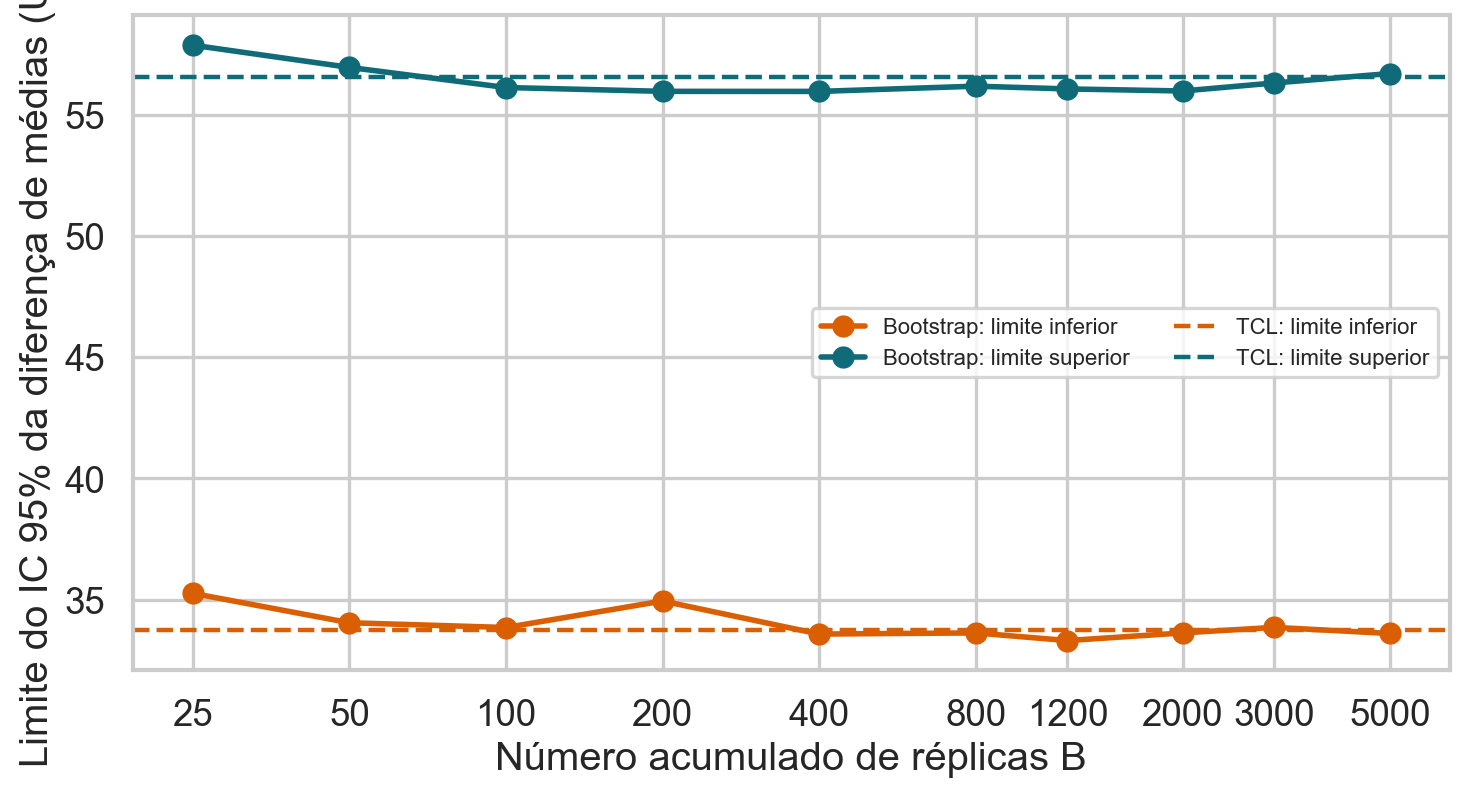

In [ ]:
def cluster_sample(group, rng):
    hosts = group["host_id"].unique()
    chosen = rng.choice(hosts, len(hosts), replace=True)
    return pd.concat([
        group[group["host_id"].eq(host)] for host in chosen
    ], ignore_index=True)

> **Interpretação**
>
> Sortear anúncios individualmente trataria unidades do mesmo anfitrião
> como independentes. O bootstrap por conglomerados preserva essa
> dependência interna e faz a incerteza refletir melhor a unidade que
> efetivamente foi amostrada.

## Quando o bootstrap é válido?

O bootstrap comum funciona melhor quando a amostra representa a
população, as observações são aproximadamente i.i.d. e a estatística
muda de maneira regular quando a distribuição é perturbada. Ele não
corrige viés de seleção, não cria eventos que não apareceram na amostra
e pode falhar para máximos, caudas raras, amostras pequenas ou dados
dependentes.

Antes de reamostrar, verifique:

1.  qual é a população-alvo;
2.  qual é a unidade independente;
3.  se o esquema de reamostragem imita a coleta;
4.  se os limites são estáveis quando $R$ aumenta;
5.  se conclusões mudam sob métodos de intervalo alternativos.

## Erros comuns

- confundir $R$, número de réplicas, com $n$, tamanho da amostra;
- sortear sem reposição;
- interpretar o intervalo como probabilidade posterior do parâmetro;
- reamostrar linhas quando a independência ocorre por anfitrião, escola
  ou dia;
- acreditar que milhares de réplicas compensam poucos dados ou coleta
  enviesada.

## Perguntas

1.  Por que o bootstrap comum sorteia com reposição?
2.  O que muda quando aumentamos $R$? E quando aumentamos $n$?
3.  Por que reamostrar anúncios pode subestimar a incerteza?
4.  Em quais situações o bootstrap percentil seria inadequado?

# Guia teórico consolidado

## O princípio do bootstrap

$F(x)=P(X\leq x)$ é a CDF da população desconhecida. Sua versão
empírica é

$$\widehat F_n(x)=\frac1n\sum_{i=1}^n\mathbb 1(X_i\leq x),$$

em que $X_i$ é a observação $i$, $x$ é um ponto da escala e
$\mathbb 1(\cdot)$ é a função indicadora. Assim, $\widehat F_n(x)$ é a
proporção de valores menores ou iguais a $x$. Essa CDF empírica
corresponde a uma distribuição que coloca massa $1/n$ em cada observação.
O bootstrap trata essa distribuição como uma aproximação da
população e gera amostras de tamanho $n$ com reposição. Para cada
amostra calculamos

$$\widehat\theta_b^*=T(X_{1b}^*,\ldots,X_{nb}^*),\qquad b=1,\ldots,R.$$

$T$ é a regra estatística escolhida; $X_{ib}^*$ é a observação $i$ da
réplica $b$; $R$ é o número de réplicas; e o asterisco identifica
quantidades geradas condicionalmente à amostra original. Se
$\theta=T(F)$ é o parâmetro e $\widehat\theta=T(\widehat F_n)$ é a
estimativa observada, o bootstrap usa a distribuição de
$\widehat\theta^* - \widehat\theta$ para aproximar a distribuição de
$\widehat\theta-\theta$.

Uma formulação assintótica da validade é

$$
\mathcal L\!\left(\sqrt n(\widehat\theta^*-\widehat\theta)\mid X_1,\ldots,X_n\right)
\Rightarrow
\mathcal L\!\left(\sqrt n(\widehat\theta-\theta)\right),
$$

Para qualquer variável aleatória genérica $Z$, $\mathcal L(Z)$ denota
sua distribuição de probabilidade. Na expressão acima, o operador
$\mathcal L$ é aplicado a duas variáveis aleatórias específicas: o erro
bootstrap padronizado $\sqrt n(\widehat\theta^*-\widehat\theta)$ e o
erro amostral padronizado $\sqrt n(\widehat\theta-\theta)$. A barra
vertical indica condicionamento nos dados observados e $\Rightarrow$
significa convergência em distribuição.

A distribuição das réplicas aproxima, condicionalmente à amostra
observada, a distribuição amostral do estimador. Seu desvio-padrão
estima o erro padrão; quantis podem formar um intervalo percentil.

Para nível $1-\alpha$, o intervalo percentil é
$[q_{\alpha/2},q_{1-\alpha/2}]$, em que $q_\gamma$ é o quantil de ordem
$\gamma$ das réplicas. Para 95%, $\alpha=0{,}05$ e usamos os quantis
2,5% e 97,5%.

## Viés do estimador e viés estimado pelo bootstrap

O viés frequentista de um estimador é

$$B_F(\widehat\theta)=\mathbb{E}_F(\widehat\theta)-\theta,$$

em que $\mathbb{E}_F$ é a esperança sob repetidas amostras da população $F$,
$\theta=T(F)$ é o parâmetro e $\widehat\theta$ é o estimador. Não
podemos calcular essa quantidade diretamente com uma única amostra
porque $F$ e $\theta$ são desconhecidos.

No mundo bootstrap, substituímos $F$ por $\widehat F_n$ e estimamos

$$\widehat B_{boot}(\widehat\theta)
=\mathbb{E}_*(\widehat\theta^*\mid X_1,\ldots,X_n)-\widehat\theta
\approx\overline{\theta^*}-\widehat\theta,$$

onde $\mathbb{E}_*$ é a esperança sobre reamostragens condicionadas nos dados
observados e $\overline{\theta^*}=R^{-1}\sum_{b=1}^R\widehat\theta_b^*$
é a média das réplicas. Uma correção pontual simples seria

$$\widehat\theta_{corr}=\widehat\theta-\widehat B_{boot}(\widehat\theta)
=2\widehat\theta-\overline{\theta^*}.$$

Essa correção não deve ser aplicada automaticamente. A estimativa do
viés também tem erro de Monte Carlo e erro amostral; em estimadores
irregulares ou amostras pequenas, subtrair o viés estimado pode aumentar
o MSE. Além disso, esse cálculo trata apenas do viés que a distribuição
empírica consegue reproduzir.

É essencial distinguir:

- **viés do estimador:** deslocamento médio provocado pela regra
  estatística sob amostras repetidas;
- **viés bootstrap estimado:** aproximação desse deslocamento
  condicionada à amostra observada;
- **viés de seleção ou mensuração:** diferença causada por uma amostra
  não representativa ou dados medidos incorretamente, que o bootstrap
  comum geralmente replica em vez de corrigir.

### Exemplo numérico: corrigindo o estimador do máximo

Considere a amostra observada

$$x=(2,4)$$

e suponha que queremos estimar o maior valor da população com

$$\widehat\theta=\max(x_1,x_2)=4.$$

A distribuição empírica coloca probabilidade $1/2$ em 2 e $1/2$ em 4. Ao
sortear duas observações com reposição, existem quatro amostras
bootstrap ordenadas igualmente prováveis:

| amostra bootstrap $x^*$ | $\widehat\theta^*=\max(x^*)$ |
|-------------------------|-----------------------------:|
| $(2,2)$                 |                            2 |
| $(2,4)$                 |                            4 |
| $(4,2)$                 |                            4 |
| $(4,4)$                 |                            4 |

Como todas têm probabilidade $1/4$, a esperança bootstrap do estimador é

$$
\mathbb{E}_*(\widehat\theta^*)
=\overline{\theta^*}
=\frac{2+4+4+4}{4}
=3{,}5.
$$

Logo, o viés bootstrap estimado é

$$
\widehat B_{boot}(\widehat\theta)
=\overline{\theta^*}-\widehat\theta
=3{,}5-4
=-0{,}5.
$$

O sinal negativo indica que, no mundo bootstrap, o máximo tende a ficar
abaixo do máximo observado. Aplicando a correção usual,

$$
\widehat\theta_{corr}
=\widehat\theta-\widehat B_{boot}(\widehat\theta)
=4-(-0{,}5)
=4{,}5.
$$

Equivalentemente,

$$
\widehat\theta_{corr}
=2\widehat\theta-\overline{\theta^*}
=2(4)-3{,}5
=4{,}5.
$$

In [ ]:
from itertools import product

x_simples = np.array([2, 4])
amostras_possiveis = np.array(list(product(x_simples, repeat=2)))
maximos_bootstrap = amostras_possiveis.max(axis=1)

theta_hat_simples = x_simples.max()
bias_simples = maximos_bootstrap.mean() - theta_hat_simples
theta_corrigido_simples = theta_hat_simples - bias_simples

pd.DataFrame({
    "amostra bootstrap": [tuple(v) for v in amostras_possiveis],
    "máximo": maximos_bootstrap,
}), pd.Series({
    "estimativa observada": theta_hat_simples,
    "média bootstrap": maximos_bootstrap.mean(),
    "viés bootstrap": bias_simples,
    "estimativa corrigida": theta_corrigido_simples,
})

> **O que o exemplo ensina**
>
> A correção desloca a estimativa na direção oposta ao viés estimado.
> Entretanto, o máximo é um estimador pouco regular e a amostra tem
> apenas duas observações: obter 4,5 não garante melhora em MSE nem
> revela valores da população que nunca apareceram na amostra. O exemplo
> serve para tornar a fórmula transparente, não para recomendar correção
> automática.

In [ ]:
bias_boot = replicas.mean() - theta_hat
theta_corrigido = theta_hat - bias_boot
pd.Series({
    "estimativa observada": theta_hat,
    "viés bootstrap estimado": bias_boot,
    "estimativa corrigida": theta_corrigido,
})

Com a semente usada neste material, o resultado é:

| quantidade              | valor (US\$) |
|-------------------------|-------------:|
| estimativa observada    |        40,00 |
| viés bootstrap estimado |        −0,26 |
| estimativa corrigida    |        40,26 |

> **Interpretação**
>
> Um centro bootstrap próximo de $\widehat\theta$ sugere pouco viés
> estimável para essa estatística e essa distribuição empírica. Isso não
> demonstra que a amostra Airbnb represente todos os anúncios, nem
> corrige dependência entre anúncios do mesmo anfitrião.

## A correção pontual não garante a cobertura

Corrigir $\widehat\theta$ trata o deslocamento da **estimativa
pontual**, mas isso não garante que um intervalo tenha a cobertura
nominal. O intervalo também precisa posicionar corretamente suas duas
caudas. O método percentil usa diretamente a distribuição das réplicas e
funciona melhor quando ela representa adequadamente tanto a posição
quanto a forma da distribuição amostral do estimador. Dois problemas
ajudam a entender por que outros intervalos foram propostos.

O primeiro é o **deslocamento**. Se
$\mathbb E_*(\widehat\theta^*)-\widehat\theta\neq0$, o centro das
réplicas não coincide com a estimativa observada. Esse deslocamento médio
é a estimativa bootstrap do viés. Os quantis percentis também carregam o
deslocamento e podem precisar ser reposicionados.

O segundo é a **variabilidade não constante**. A sensibilidade da
estatística às observações pode mudar em diferentes regiões da
distribuição. Como consequência, uma cauda da distribuição do estimador
pode se alongar mais do que a outra. Um único erro-padrão ou um ajuste
simétrico não representa igualmente essas duas direções. O *jackknife*
usado no BCa estima essa mudança por meio do coeficiente de aceleração
$a$.

Quando esses efeitos são pequenos, percentil, básico, Normal e BCa
costumam produzir limites semelhantes. Diferenças relevantes entre eles
indicam que deslocamento, assimetria, tamanho amostral ou irregularidade
do estimador merecem atenção.

## Resumo das técnicas de intervalo

Considere $R$ réplicas $\widehat\theta_1^*,\ldots,\widehat\theta_R^*$.
Denote por $q_\gamma^*$ o quantil de ordem $\gamma$ dessas réplicas, por
$\widehat\theta$ a estimativa observada e por
$z_\gamma=\Phi^{-1}(\gamma)$ o quantil de ordem $\gamma$ da Normal
padrão. Os métodos abaixo usam a mesma reamostragem, mas transformam a
distribuição bootstrap de formas diferentes.

| Método | Informação usada | Cálculo | O que faz |
|---|---|---|---|
| Percentil | quantis de $\widehat\theta_b^*$ | $[q_{\alpha/2}^*,q_{1-\alpha/2}^*]$ | mantém a assimetria vista nas réplicas, sem correção explícita de deslocamento |
| Básico | quantis de $\widehat\theta_b^*-\widehat\theta$ | $[2\widehat\theta-q_{1-\alpha/2}^*,2\widehat\theta-q_{\alpha/2}^*]$ | reflete as distâncias das caudas em torno da estimativa observada |
| Normal | desvio-padrão das réplicas | $\widehat\theta\pm z_{1-\alpha/2}\widehat{SE}_{boot}$ | força simetria e resume a incerteza por um único erro padrão |
| BCa (*bias-corrected and accelerated*) | quantis, posição de $\widehat\theta$ e *jackknife* | $[q_{\alpha_1^{BCa}}^*,q_{\alpha_2^{BCa}}^*]$ | ajusta os níveis dos quantis para viés e mudança de variabilidade |

A tabela fornece o mapa geral. As próximas subseções apresentam a fórmula,
as vantagens e as limitações de cada construção.

### Intervalo percentil

O intervalo percentil de nível $1-\alpha$ é

$$IC_{perc}=\left[q_{\alpha/2}^*,\ q_{1-\alpha/2}^*\right].$$

Ele usa diretamente os quantis da distribuição de $\widehat\theta^*$.

**Vantagens:** é simples, respeita transformações monótonas e pode
produzir limites assimétricos quando as réplicas são assimétricas. Sua
interpretação computacional é direta.

**Desvantagens:** não corrige explicitamente o viés de $\widehat\theta$
e pode ter cobertura ruim quando a distribuição bootstrap está
deslocada, a amostra é pequena ou o estimador é pouco regular.

### Intervalo básico

O intervalo básico reflete os quantis bootstrap em torno da estimativa
observada:

$$IC_{bas}=\left[2\widehat\theta-q_{1-\alpha/2}^*,\ 2\widehat\theta-q_{\alpha/2}^*\right].$$

A motivação é aproximar a distribuição do erro $\widehat\theta-\theta$
pela distribuição de $\widehat\theta^*-\widehat\theta$ e inverter os
limites para isolar $\theta$.

Mais explicitamente, os quantis do erro bootstrap são
$q_\gamma^*-\widehat\theta$. Portanto,

$$
\begin{aligned}
IC_{bas}
&=\left[\widehat\theta-(q_{1-\alpha/2}^*-\widehat\theta),\
\widehat\theta-(q_{\alpha/2}^*-\widehat\theta)\right]\\
&=\left[2\widehat\theta-q_{1-\alpha/2}^*,\
2\widehat\theta-q_{\alpha/2}^*\right].
\end{aligned}
$$

Por exemplo, se $\widehat\theta=10$ e os quantis bootstrap são
$[8,13]$, o intervalo básico é $[20-13,20-8]=[7,12]$. A distribuição
bootstrap se estende 3 unidades acima e 2 abaixo da estimativa. O
intervalo básico reflete essas distâncias, ficando 3 unidades abaixo e
2 acima de $\widehat\theta$.

> **Relação com o viés bootstrap**
>
> O deslocamento médio das réplicas,
> $\widehat B_{boot}(\widehat\theta)=\overline{\theta^*}-\widehat\theta$, é a
> estimativa bootstrap do viés. O intervalo básico, porém, usa os dois
> quantis da distribuição do erro, e não apenas esse deslocamento médio.
> Quando a distribuição bootstrap sofre essencialmente uma translação, a
> reflexão também corrige o deslocamento associado ao viés; com assimetria,
> cada cauda pode exigir uma distância diferente.

**Vantagens:** faz uma correção simples de deslocamento e está
diretamente ligado à distribuição bootstrap do erro do estimador.

**Desvantagens:** não é invariante a transformações monótonas. Um
intervalo calculado para $\log(\theta)$ e depois transformado de volta
pode diferir daquele calculado diretamente para $\theta$. Também não
corrige adequadamente assimetria complexa.

### Intervalo Normal com erro padrão bootstrap

O intervalo Normal é

$$IC_{N}=\left[\widehat\theta-z_{1-\alpha/2}\widehat{SE}_{boot},\ \widehat\theta+z_{1-\alpha/2}\widehat{SE}_{boot}\right],$$

com

$$\widehat{SE}_{boot}=\sqrt{\frac{1}{R-1}\sum_{b=1}^R\left(\widehat\theta_b^*-\overline{\theta^*}\right)^2},$$

onde $\overline{\theta^*}=R^{-1}\sum_b\widehat\theta_b^*$ é a média das
réplicas.

**Vantagens:** é familiar, fácil de comunicar e costuma funcionar bem
quando a distribuição do estimador é aproximadamente Normal, simétrica e
com viés pequeno. Para médias em amostras grandes, aproxima-se
naturalmente do intervalo derivado pelo TCL.

**Desvantagens:** força simetria ao redor de $\widehat\theta$, mesmo
quando a distribuição bootstrap é assimétrica. Pode gerar limites
impossíveis para parâmetros restritos, como probabilidades próximas de
zero ou um.

### Intervalo BCa

BCa significa *bias-corrected and accelerated*, ou **corrigido por viés
e aceleração**. Ele continua usando quantis bootstrap, mas substitui
$\alpha/2$ e $1-\alpha/2$ por probabilidades ajustadas:

$$
\alpha_j^{BCa}=\Phi\!\left[z_0+
\frac{z_0+z_{\alpha_j}}{1-a(z_0+z_{\alpha_j})}\right],
\qquad \alpha_1=\alpha/2,\quad \alpha_2=1-\alpha/2,
$$

e constrói

$$IC_{BCa}=\left[q_{\alpha_1^{BCa}}^*,\ q_{\alpha_2^{BCa}}^*\right].$$

Na fórmula, $\Phi$ é a CDF da Normal padrão; $z_0$ é a correção de viés,
estimada pela posição de $\widehat\theta$ entre as réplicas; e $a$ é a
aceleração, que mede como o erro padrão muda com o parâmetro. Uma
estimativa usual de $z_0$ é

$$z_0=\Phi^{-1}\!\left(\frac{\#\{\widehat\theta_b^*<\widehat\theta\}}{R}\right).$$

A aceleração é normalmente calculada por *jackknife*: removemos uma
observação por vez, calculamos $\widehat\theta_{(-i)}$ e usamos

$$
a=\frac{\sum_{i=1}^n(\overline\theta_{(-\cdot)}-\widehat\theta_{(-i)})^3}
{6\left[\sum_{i=1}^n(\overline\theta_{(-\cdot)}-\widehat\theta_{(-i)})^2\right]^{3/2}},
$$

onde $\widehat\theta_{(-i)}$ é a estimativa sem a observação $i$ e
$\overline\theta_{(-\cdot)}=n^{-1}\sum_i\widehat\theta_{(-i)}$ é a média
das estimativas *jackknife*.

O cálculo pode ser lido em três etapas. Primeiro,
$p_0=R^{-1}\#\{\widehat\theta_b^*<\widehat\theta\}$ localiza a
estimativa observada na distribuição bootstrap e
$z_0=\Phi^{-1}(p_0)$ traduz essa posição para a escala Normal. Segundo,
o *jackknife* calcula $a$ para detectar mudanças na variabilidade quando
as observações mudam. Por fim, $z_0$ e $a$ transformam os níveis nominais
$\alpha/2$ e $1-\alpha/2$ nos níveis ajustados $\alpha_1^{BCa}$ e
$\alpha_2^{BCa}$.

No exemplo da diferença de medianas, encontramos $z_0=-0{,}159$ e
$a=0$. Assim, os níveis nominais 2,5% e 97,5% tornam-se aproximadamente
1,13% e 94,96%. Os quantis correspondentes das réplicas produzem
$IC_{BCa}\approx[28,50]$ dólares, em vez de simplesmente selecionar os
quantis percentis $[30,51]$.

#### Exercício resolvido: um BCa simplificado

Em um bootstrap com $R=1.000$ réplicas, 600 estimativas ficaram abaixo
de $\widehat\theta$. Considere $a=0$ e um intervalo de 95%. Calcule
$p_0$, $z_0$, os níveis ajustados e o intervalo, sabendo que
$q_{0{,}073}^*=18{,}4$ e $q_{0{,}993}^*=27{,}9$.

Primeiro,

$$p_0=\frac{600}{1.000}=0{,}60,
\qquad z_0=\Phi^{-1}(0{,}60)\approx0{,}253.$$

Como $a=0$, a fórmula dos níveis ajustados reduz-se a
$\alpha_j^{BCa}=\Phi(2z_0+z_{\alpha_j})$. Portanto,

$$\alpha_1^{BCa}=\Phi(2\times0{,}253-1{,}96)
=\Phi(-1{,}454)\approx0{,}073,$$

$$\alpha_2^{BCa}=\Phi(2\times0{,}253+1{,}96)
=\Phi(2{,}466)\approx0{,}993.$$

Finalmente,

$$IC_{BCa}=[q_{0{,}073}^*,q_{0{,}993}^*]=[18{,}4,27{,}9].$$

> **Interpretação**
>
> O valor $z_0>0$ indica que $\widehat\theta$ está acima do centro das
> réplicas. O BCa desloca os dois níveis para cima, substituindo 2,5% e
> 97,5% por 7,3% e 99,3%. O exercício usa $a=0$ apenas para isolar o
> efeito da correção de viés.

**Vantagens:** corrige deslocamento e assimetria, é invariante a
transformações monótonas e costuma apresentar melhor precisão de
cobertura em problemas regulares.

**Desvantagens:** é mais custoso e menos transparente, pois exige
bootstrap e *jackknife*. Pode ser instável em amostras pequenas, com
estatísticas não suaves, parâmetros na fronteira ou observações
extremamente influentes. “Mais sofisticado” não compensa uma amostra não
representativa ou uma unidade de reamostragem incorreta.

> **Empates podem tornar a aceleração indefinida**
>
> Na amostra usada nesta aula, os preços inteiros produzem muitos empates
> perto das medianas. Todas as estimativas *jackknife* da diferença de
> medianas ficam iguais e o denominador da fórmula de $a$ vale zero. Na
> comparação visual, adotamos $a=0$, de modo que o intervalo mantém a
> correção de viés $z_0$, mas não aplica correção de aceleração. Esse caso
> mostra por que o BCa pode ser instável para estatísticas não suaves e
> dados discretizados.

| Método | Melhor cenário | Principal limitação |
|------------------------|------------------------|------------------------|
| Percentil | distribuição bootstrap com pouco viés | não corrige deslocamento |
| Básico | erro bootstrap aproximadamente bem representado | não é invariante a transformações |
| Normal | estimador aproximadamente Normal e simétrico | ignora assimetria e restrições do parâmetro |
| BCa | problema regular com viés ou assimetria moderados | maior custo e possível instabilidade |

> **Como escolher**
>
> Não existe um intervalo universalmente melhor. Compare métodos,
> examine a distribuição bootstrap e verifique cobertura por simulação
> quando possível. Discordâncias relevantes são diagnóstico de viés,
> assimetria, pouca informação ou falta de regularidade — não um convite
> para escolher apenas o intervalo que produz a conclusão desejada.


## Teste de hipótese e p-valor bootstrap

O intervalo de confiança descreve uma faixa de valores compatíveis com
os dados. Para calcular um p-valor, precisamos da distribuição da
estatística **quando a hipótese nula é verdadeira**.

Para as medianas populacionais de Manhattan e Brooklyn, definimos

$$H_0:\Delta=m_M-m_B=0\qquad\text{e}\qquad H_A:\Delta\neq0.$$

O bootstrap usual fica centrado perto de $\widehat\Delta=40$ e
aproxima naturalmente a distribuição sob a alternativa observada. Para
impor $H_0$, recentralizamos cada grupo:

$$X_{gi}^{(0)}=X_{gi}-\widetilde X_g,\qquad g\in\{M,B\}.$$

$X_{gi}$ é a observação $i$ do grupo $g$; $\widetilde X_g$ é sua
mediana amostral; e $X_{gi}^{(0)}$ é o valor recentralizado. Os dois
grupos passam a ter mediana zero, mas preservam suas formas e dispersões.


In [ ]:
manhattan_h0 = prices["Manhattan"] - np.median(prices["Manhattan"])
brooklyn_h0 = prices["Brooklyn"] - np.median(prices["Brooklyn"])

test_rng = np.random.default_rng(1212)
n_rep_test = 10_000
idx_m = test_rng.integers(0, len(manhattan_h0), (n_rep_test, len(manhattan_h0)))
idx_b = test_rng.integers(0, len(brooklyn_h0), (n_rep_test, len(brooklyn_h0)))
null_replicas = (
    np.median(manhattan_h0[idx_m], axis=1)
    - np.median(brooklyn_h0[idx_b], axis=1)
)
n_extreme = np.sum(np.abs(null_replicas) >= np.abs(theta_hat))
p_boot = (1 + n_extreme) / (n_rep_test + 1)

sns.histplot(null_replicas, bins=np.arange(-20.5, 25.6, 1), stat="density")
plt.axvline(-abs(theta_hat), color="#d95f02", linestyle="--")
plt.axvline(abs(theta_hat), color="#d95f02", linestyle="--")
plt.xlim(-45, 45)
plt.xlabel("Diferença de medianas sob H0 (US$)")
plt.show()

pd.Series({
    "diferença observada": theta_hat,
    "réplicas sob H0": n_rep_test,
    "excedências": n_extreme,
    "p-valor bootstrap": p_boot,
})

O p-valor bilateral é estimado por

$$\widehat p_{boot}=\frac{1+\sum_{b=1}^{R}\mathbb 1\{|T_b^{*(0)}|\geq|T_{obs}|\}}{R+1}.$$

$T_{obs}$ é a diferença observada; $T_b^{*(0)}$ é a diferença na réplica
$b$ gerada sob $H_0$; e $R$ é o total de réplicas. Somar 1 ao numerador
e ao denominador evita reportar zero por limitação da simulação.

> **Interpretação**
>
> Nenhuma das 10.000 réplicas nulas atingiu uma diferença absoluta de
> US$ 40. Assim, $\widehat p_{boot}=1/10.001\approx0{,}0001$, forte
> evidência contra $H_0$ dentro do modelo de reamostragem. Se anúncios do
> mesmo anfitrião forem dependentes, o teste deve reamostrar anfitriões.

> **Intervalo e teste devem usar hipóteses compatíveis**
>
> Um intervalo percentil que não contém zero costuma apontar na mesma
> direção de um teste bilateral, mas a equivalência não é automática
> quando as construções são diferentes. Este p-valor vem explicitamente
> de uma distribuição recentralizada sob $H_0$.

## O que torna a aproximação válida

Para um intervalo de nível $1-\alpha$, a cobertura frequentista é

$$P_F\{\theta\in CI(X_1,\ldots,X_n)\}\approx1-\alpha.$$

$P_F$ é a probabilidade em amostras repetidas da população $F$;
$CI(X_1,\ldots,X_n)$ é o intervalo produzido pela amostra; $\theta$ é
o parâmetro fixo; e $1-\alpha$ é a cobertura desejada.

O bootstrap costuma funcionar quando a amostra representa a população, a
unidade reamostrada corresponde à unidade independente e a estatística
varia de maneira suficientemente regular. Ele pode falhar em amostras
pequenas, extremos, parâmetros na fronteira, caudas não observadas,
forte dependência ou seleção enviesada.

Reposição é indispensável: sem ela, toda réplica seria apenas uma
reordenação da mesma amostra. Mais réplicas reduzem erro de Monte Carlo,
mas não criam informação nem compensam poucos dados.

## Unidade de reamostragem

Anúncios do mesmo anfitrião podem ser dependentes. Reamostrar anúncios
individualmente pressupõe independência entre anúncios; reamostrar
anfitriões preserva a dependência interna. Séries temporais podem exigir
blocos; amostras estratificadas podem exigir reamostragem dentro dos
estratos.

O método de intervalo não corrige uma unidade de reamostragem
inadequada. Percentil, básico, Normal e BCa podem discordar,
especialmente quando a distribuição bootstrap é assimétrica ou
enviesada.

# Questões de revisão da Aula 12

1.  Por que uma réplica bootstrap de tamanho $n$ é sorteada com
    reposição?
2.  Se anúncios do mesmo anfitrião são dependentes, qual deve ser a
    unidade de reamostragem?
3.  Por que o bootstrap usual precisa ser recentralizado para calcular
    o p-valor de $H_0:\Delta=0$?

Respostas comentadas

1.  Com reposição, algumas observações se repetem e outras ficam
    ausentes, fazendo a estatística variar. Sem reposição, teríamos
    apenas uma reordenação da amostra.
2.  O anfitrião deve ser reamostrado como conglomerado, carregando seus
    anúncios. Aumentar $R$ não corrige dependência ignorada.
3.  O bootstrap usual fica centrado perto da diferença observada e
    aproxima a distribuição sob a alternativa. A recentralização força
    os grupos a satisfazerem $H_0$, permitindo medir quão extremo é
    $T_{obs}$ nessa distribuição nula.